# The microprice

An estimator of the fair price, given the state of the order book

KISS

https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2970694

# Big question:

What is the fair price, given the bid/ask prices and sizes?

We will call this notion of fair price the microprice.

This notion can be useful to algorithmic traders, HFT, market makers, etc...


# Definitions

The bid, ask, bid size, ask size: $P^b, P^a, Q^b, Q^a$

The mid-price: $$M=\frac{P^b+P^a}{2}$$

The weighted mid-price: $$M=P^b (1-I) +P^a I$$

The imbalance: $$I=\frac{Q_b}{Q_b+Q_a}$$

The bid-ask spread: $$S=(P^a-P^b)$$


In [108]:
import pandas as pd
import numpy as np

In [109]:
try:
    import nest_asyncio
    nest_asyncio.apply()
except Exception:
    pass

try:
    from tardis_dev import datasets
except ImportError:
    datasets = None

DATA_PATH = "./datasets/bitmex_book_snapshot_5_2025-04-01_XBTUSD.csv.gz"
TEST_NROWS = 100000



# if datasets is not None:
#     dataset = datasets.download(
#         exchange="bitmex",
#         data_types=["book_snapshot_5"],
#         from_date="2025-04-01",
#         to_date="2025-04-01",
#         symbols=["XBTUSD"]
#     )

df = pd.read_csv(DATA_PATH, nrows=TEST_NROWS)
df.head()


,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,...,time_s,bid,ask,bs,as,mid,imb,wmid,microprice_adjustment,microprice_estimate
0,bitmex,XBTUSD,1743465600124000,1743465600237850,82510.4,5000,82505.1,500,82510.6,5500,...,0.000,82505.1,82510.4,500.0,5000.0,82507.75,0.090909,82505.581818,NaN,NaN
1,bitmex,XBTUSD,1743465600112000,1743465600244104,82510.3,17500,82505.1,500,82510.4,5000,...,-0.012,82505.1,82510.3,500.0,17500.0,82507.70,0.027778,82505.244444,NaN,NaN
2,bitmex,XBTUSD,1743465600115000,1743465600244112,82510.4,5000,82505.1,500,82510.6,5500,...,-0.009,82505.1,82510.4,500.0,5000.0,82507.75,0.090909,82505.581818,NaN,NaN
3,bitmex,XBTUSD,1743465600116000,1743465600244112,82510.4,5000,82505.1,500,82510.6,5500,...,-0.008,82505.1,82510.4,500.0,5000.0,82507.75,0.090909,82505.581818,NaN,NaN
4,bitmex,XBTUSD,1743465600121000,1743465600244117,82510.4,5000,82505.1,500,82510.6,5500,...,-0.003,82505.1,82510.4,500.0,5000.0,82507.75,0.090909,82505.581818,NaN,NaN


<Axes: xlabel='t_seconds_from_start'>

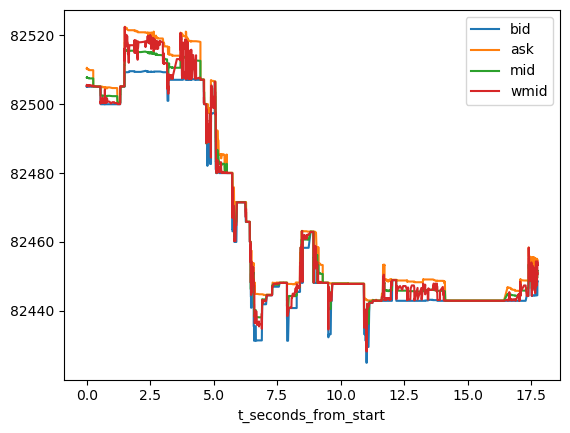

In [110]:
def compute_definitions(df):
    # keep only the columns you need
    df = df[['timestamp', 'bids[0].price', 'bids[0].amount', 'asks[0].price', 'asks[0].amount']].copy()

    df = df.dropna()

    df['time'] = df['timestamp'].astype(float)
    df['bid'] = df['bids[0].price'].astype(float)
    df['ask'] = df['asks[0].price'].astype(float)
    df['bs'] = df['bids[0].amount'].astype(float)
    df['as'] = df['asks[0].amount'].astype(float)

    df['mid'] = (df['bid'] + df['ask']) / 2
    df['imb'] = df['bs'] / (df['bs'] + df['as'])
    df['wmid'] = df['ask'] * df['imb'] + df['bid'] * (1 - df['imb'])

    return df

data = compute_definitions(df)

data['t_seconds_from_start'] = (data['timestamp'] - data['timestamp'].iloc[0]) / 1_000_000

data.iloc[:3000].plot(
    x='t_seconds_from_start',
    y=['bid', 'ask', 'mid', 'wmid']
)

# The mid vs. the weighted mid

The mid-price:
- Not a martingale (Bid-ask bounce)
- Medium frequency signal 
- Doesn't use volume at the best bid and ask prices. 

The weighted mid-price:
- Uses the volume at the best bid and ask prices.
- High frequency signal
- Is quite noisy, particularly when the spread widens to two ticks

# Desirable features of the Micro-Price

 $P_t^{micro}=F(M_t,I_t,S_t) = M_t+ G(I_t,S_t)$ 
- Martingale
- Computationally fast
- Better short term price predictions than the midprice or weighted midprice
- Should work for large tick stocks (like BAC) or small tick stocks (like CVX)

# Outline

1. General definition
2. A discrete Markov model
3. Data analysis
4. Conclusion

# Micro-price definition

Define
\begin{equation*}
P_t^{micro}=\lim_{n\to\infty} P_t^n
\end{equation*}
where the approximating sequence of martingale prices is given by
$$P^n_t=\mathbb{E} \left[  M_{\tau_n} |  I_t,S_t \right] $$

$\tau_1,...,\tau_n$ are (random) times when the mid-price $M_t$ changes
 
The micro-price is the expected mid-price in the distant future
 
In practice, the distant future is well captured by $P_t^6$, the expected mid price after 6 price moves.

# Main result


The $i$-th approximation to the micro-price can be written as
\begin{equation*}
P_t^{n} =  M_t + \sum_{k=1}^{n}g^k(I_t,S_t) 
\end{equation*}
where
$$g^1(I_t,S_t)= \mathbb{E}  \left[  M_{\tau_1} - M_t  | I_t, S_t \right] $$
and
$$
g^{n+1}(I_t,S_t)= \mathbb{E}\left[ g^n(I_{\tau_{1}},S_{\tau_{1}}) | I_{t},S_t\right], \forall j\geq 0
$$
can be computed recursively.

# Finite state Markov chain

- The imbalance takes discrete values $1\leq i_I \leq n$, 
- The spread takes discrete values $1\leq i_S \leq m$
- The mid-price changes takes values in $K =[-0.01 \quad -0.005 \quad 0.005 \quad 0.01]$. 
- Define the state $X_t=(I_t,S_t)$ with discrete values $1\leq i \leq nm$

# Computing $g^1$

The first step approximation to the micro-price 
\begin{align*}
g^1(i) = &  \mathbb{E} \left[M_{\tau_{1}}- M_{t} | X_t= i \right] \\
= {}& \big(1-Q\big)^{-1}R^1\underline{k}
\end{align*}

Where
$Q_{ij} := \mathbb{P}(M_{t+1}- M_t =0 \wedge X_{t+1}=j | X_t= i)$
are the transition probabilities for transient states (mid price does not move) 

$R^1_{ik} := \mathbb{P}(M_{t+1}- M_t =k | X_t = i)$ are the transition probabilities into absorbing states (mid price does move) 

and $\underline{k}=[-0.01 \quad -0.005 \quad 0.005 \quad 0.01]^T$ 

# Computing $g^{i+1}$


We can compute recursively
\begin{align*}
g^{n+1}=  B g^n
\end{align*}
where $B:=\big(1-Q\big)^{-1}R^2$

and $R^2$ is a new matrix of absorbing states
\begin{align*}
R^2_{ik} := {}& \mathbb{P}(M_{t+1}- M_t \neq 0 \wedge I_{t+1}=k  | I_t = i)
\end{align*}

# Does the micro-price converge?

Yes. But we have to appropriately symmetrize the data.

Technical conditions are available in the paper.


# BTC Estimation

1. On every quote, compute $I_t, S_t, (M_{t+1}-M_t)$, after having discretized the state space
2. Symmetrize the data, by making a copy where $I^2_t=n-I_t, S^2_t=S_t, (M^2_{t+1}-M^2_t)=-(M_{t+1}-M_t)$
3. Estimate transition probability matrices $Q, R^1, R^2$
 
# Computation

Compute the first micro-price adjustment:
$$p^{1}-M = g^1 = \big(1-Q\big)^{-1}R^1\underline{k}$$
Use our recursive formula to compute the 6th micro-price adjustment:
$$p^{6}-M = g^1+g^2+ \ldots +g^6 = g^1 + B g^1 + \ldots + B^5 g^1 $$
In practice this converges after 6 price moves

In [111]:
def prep_data_sym(T, n_imb, dt, n_spread):
    T = T.copy()
    T['source_index'] = T.index
    spread = T.ask - T.bid
    ticksize = np.round(min(spread.loc[spread > 0]) * 100) / 100
    T.spread = T.ask - T.bid
    # adds the spread and mid prices
    T['spread'] = np.round((T['ask'] - T['bid']) / ticksize) * ticksize
    T['mid'] = (T['bid'] + T['ask']) / 2
    # filter out spreads >= n_spread
    T = T.loc[(T.spread <= n_spread * ticksize) & (T.spread > 0)].copy()
    T['imb'] = T['bs'] / (T['bs'] + T['as'])
    # discretize imbalance into percentiles
    T['imb_bucket'] = pd.qcut(T['imb'], n_imb, labels=False, duplicates='drop')
    T['next_mid'] = T['mid'].shift(-dt)
    # step ahead state variables
    T['next_spread'] = T['spread'].shift(-dt)
    T['next_time'] = T['time'].shift(-dt)
    T['next_imb_bucket'] = T['imb_bucket'].shift(-dt)
    # step ahead change in price
    T['dM'] = np.round((T['next_mid'] - T['mid']) / ticksize * 2) * ticksize / 2
    T = T.loc[(T.dM <= ticksize * 1.1) & (T.dM >= -ticksize * 1.1)].copy()

    # keep the original, non-symmetrized sample so we can map estimates back
    T_orig = T.copy(deep=True)

    # symetrize data
    T2 = T.copy(deep=True)
    T2['imb_bucket'] = n_imb - 1 - T2['imb_bucket']
    T2['next_imb_bucket'] = n_imb - 1 - T2['next_imb_bucket']
    T2['dM'] = -T2['dM']
    T2['mid'] = -T2['mid']
    T3 = pd.concat([T, T2])
    T3.index = pd.RangeIndex(len(T3.index))
    return T3, ticksize, T_orig


In [112]:
from scipy.linalg import block_diag

def estimate(T):
    no_move=T[T['dM']==0]
    no_move_counts=no_move.pivot_table(index=[ 'next_imb_bucket'], 
                     columns=['spread', 'imb_bucket'], 
                     values='time',
                     fill_value=0, 
                     aggfunc='count').unstack()
    Q_counts=np.resize(np.array(no_move_counts[0:(n_imb*n_imb)]),(n_imb,n_imb))
    # loop over all spreads and add block matrices
    for i in range(1,n_spread):
        Qi=np.resize(np.array(no_move_counts[(i*n_imb*n_imb):(i+1)*(n_imb*n_imb)]),(n_imb,n_imb))
        Q_counts=block_diag(Q_counts,Qi)
    #print Q_counts
    move_counts=T[(T['dM']!=0)].pivot_table(index=['dM'], 
                         columns=['spread', 'imb_bucket'], 
                         values='time',
                         fill_value=0, 
                         aggfunc='count').unstack()

    R_counts=np.resize(np.array(move_counts),(n_imb*n_spread,4))
    T1=np.concatenate((Q_counts,R_counts),axis=1).astype(float)
    for i in range(0,n_imb*n_spread):
        T1[i]=T1[i]/T1[i].sum()
    Q=T1[:,0:(n_imb*n_spread)]
    R1=T1[:,(n_imb*n_spread):]

    K=np.array([-0.01, -0.005, 0.005, 0.01])
    move_counts=T[(T['dM']!=0)].pivot_table(index=['spread','imb_bucket'], 
                     columns=['next_spread', 'next_imb_bucket'], 
                     values='time',
                     fill_value=0, 
                     aggfunc='count') #.unstack()

    R2_counts=np.resize(np.array(move_counts),(n_imb*n_spread,n_imb*n_spread))
    T2=np.concatenate((Q_counts,R2_counts),axis=1).astype(float)

    for i in range(0,n_imb*n_spread):
        T2[i]=T2[i]/T2[i].sum()
    R2=T2[:,(n_imb*n_spread):]
    Q2=T2[:,0:(n_imb*n_spread)]
    G1=np.dot(np.dot(np.linalg.inv(np.eye(n_imb*n_spread)-Q),R1),K)
    B=np.dot(np.linalg.inv(np.eye(n_imb*n_spread)-Q),R2)
    
    return G1,B,Q,Q2,R1,R2,K

In [113]:
def compute_G6(G1, B):
    G2 = np.dot(B, G1) + G1
    G3 = G2 + np.dot(np.dot(B, B), G1)
    G4 = G3 + np.dot(np.dot(np.dot(B, B), B), G1)
    G5 = G4 + np.dot(np.dot(np.dot(np.dot(B, B), B), B), G1)
    G6 = G5 + np.dot(np.dot(np.dot(np.dot(np.dot(B, B), B), B), B), G1)
    return G6


def attach_microprice_estimate(raw_df, T_orig, G6, ticksize, n_imb, n_spread, n_moves=6):
    import numpy as np
    import pandas as pd

    df_out = raw_df.copy()

    df_out['time'] = df_out['timestamp'].astype(float)
    df_out['time_s'] = (
        df_out['timestamp'].astype(float) - df_out['timestamp'].astype(float).iloc[0]
    ) / 1e6

    df_out['bid'] = df_out['bids[0].price'].astype(float)
    df_out['ask'] = df_out['asks[0].price'].astype(float)
    df_out['bs'] = df_out['bids[0].amount'].astype(float)
    df_out['as'] = df_out['asks[0].amount'].astype(float)

    df_out['mid'] = (df_out['bid'] + df_out['ask']) / 2
    df_out['imb'] = df_out['bs'] / (df_out['bs'] + df_out['as'])
    df_out['wmid'] = df_out['ask'] * df_out['imb'] + df_out['bid'] * (1 - df_out['imb'])

    T_work = T_orig.copy().reset_index(drop=False)
    raw_index_col = T_work.columns[0]

    T_work['spread'] = np.round((T_work['ask'] - T_work['bid']) / ticksize) * ticksize
    T_work = T_work.loc[(T_work['spread'] > 0) & (T_work['spread'] <= n_spread * ticksize)].copy()

    imb_edges = np.linspace(0, 1, n_imb + 1)
    T_work['imb_bucket'] = pd.cut(
        T_work['imb'],
        bins=imb_edges,
        labels=False,
        include_lowest=True
    ).clip(0, n_imb - 1)

    spread_index = (np.round(T_work['spread'] / ticksize).astype(int) - 1)
    T_work['state_index'] = spread_index * n_imb + T_work['imb_bucket'].astype(int)

    T_work['microprice_adjustment_now'] = G6[T_work['state_index'].to_numpy()]
    T_work['microprice_estimate_now'] = T_work['mid'] + T_work['microprice_adjustment_now']

    df_out['microprice_adjustment'] = np.nan
    df_out['microprice_estimate'] = np.nan

    # only look at rows where an actual price move happened
    move_rows = T_work.index[T_work['dM'] != 0].to_numpy()

    # assign one estimate to each move row starting from the n_moves-th move
    for k in range(n_moves, len(move_rows)):
        origin_row = move_rows[k - n_moves]
        target_row = move_rows[k]

        raw_target_idx = T_work.loc[target_row, raw_index_col] + 1
        if raw_target_idx in df_out.index:
            df_out.at[raw_target_idx, 'microprice_adjustment'] = T_work.loc[origin_row, 'microprice_adjustment_now']
            df_out.at[raw_target_idx, 'microprice_estimate'] = T_work.loc[origin_row, 'microprice_estimate_now']

        df_out.at[raw_target_idx, 'microprice_adjustment'] = T_work.loc[origin_row, 'microprice_adjustment_now']
        df_out.at[raw_target_idx, 'microprice_estimate'] = T_work.loc[origin_row, 'microprice_estimate_now']

    return df_out, T_work

def plot_adjustment_and_stationary(G6, B, n_imb, n_spread, imb):
    W = np.linalg.matrix_power(B, 100)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    axes[0].plot(imb, np.linspace(-0.005, 0.005, n_imb) * 0, label='Mid adj', marker='o')
    axes[0].plot(imb, np.linspace(-0.005, 0.005, n_imb), label='Weighted mid adj', marker='o')
    for i in range(0, n_spread):
        axes[0].plot(
            imb,
            G6[(0 + i * n_imb):(n_imb + i * n_imb)],
            label="spread = " + str(i + 1) + " tick adj",
            marker='o'
        )
    axes[0].set_ylim(-0.005, 0.005)
    axes[0].legend(loc='upper left')
    axes[0].set_title('adjustments')
    axes[0].set_xlabel('Imbalance')

    for i in range(0, n_spread):
        axes[1].plot(
            imb,
            W[0][(0 + i * n_imb):(n_imb + i * n_imb)],
            label="spread = " + str(i + 1) + " tick",
            marker='o'
        )
    axes[1].legend(loc='upper left')
    axes[1].set_title('stationary distribution')
    axes[1].set_xlabel('Imbalance')

    plt.tight_layout()
    return W


In [120]:
n_imb = 10
n_spread = 2
dt = 1
n_moves = 6
imb = np.linspace(0, 1, n_imb)

pd.set_option('mode.chained_assignment', None)
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

T, ticksize, T_orig = prep_data_sym(data, n_imb, dt, n_spread)
G1, B, Q, Q2, R1, R2, K = estimate(T)
G6 = compute_G6(G1, B)

df_with_microprice, T_with_microprice = attach_microprice_estimate(
    raw_df=df,
    T_orig=T_orig,
    G6=G6,
    ticksize=ticksize,
    n_imb=n_imb,
    n_spread=n_spread,
    n_moves=n_moves,
)

df_with_microprice.to_csv(DATA_PATH, index=False, compression='gzip')
print(f"Overwrote {DATA_PATH} with {len(df_with_microprice)} rows")

df_with_microprice[['microprice_adjustment', 'microprice_estimate']].dropna().head()


Overwrote ./datasets/bitmex_book_snapshot_5_2025-04-01_XBTUSD.csv.gz with 100000 rows


,microprice_adjustment,microprice_estimate
2087,0.000054,82444.550054
2105,-0.002075,82444.597925
2106,0.000112,82444.650112
2107,0.000163,82447.050163
2787,-0.000054,82448.249946


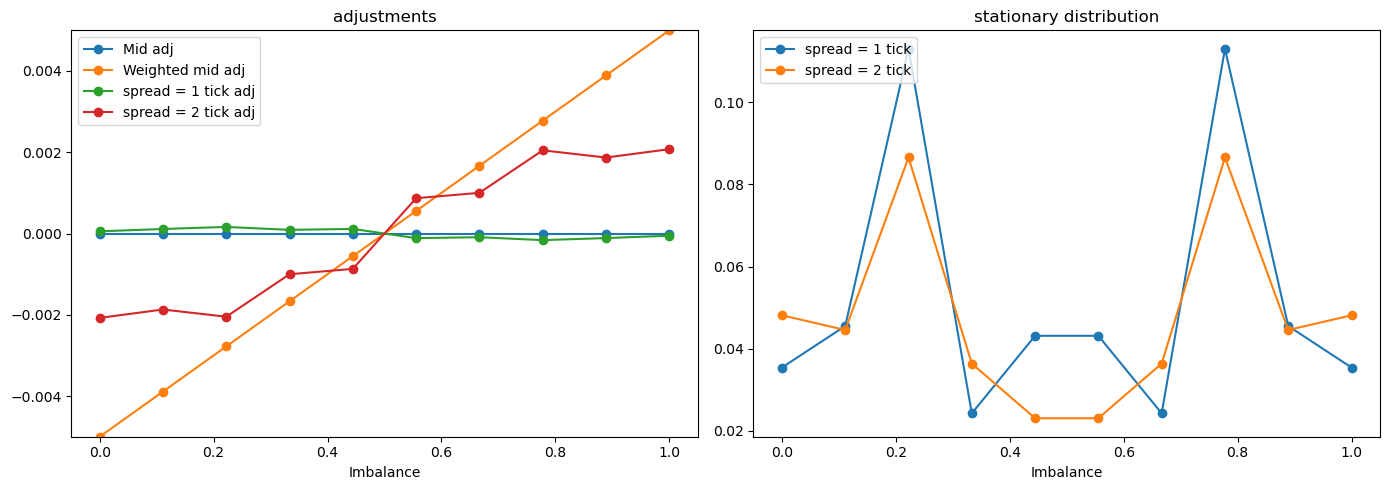

In [121]:
import matplotlib.pyplot as plt

W = plot_adjustment_and_stationary(G6, B, n_imb, n_spread, imb)


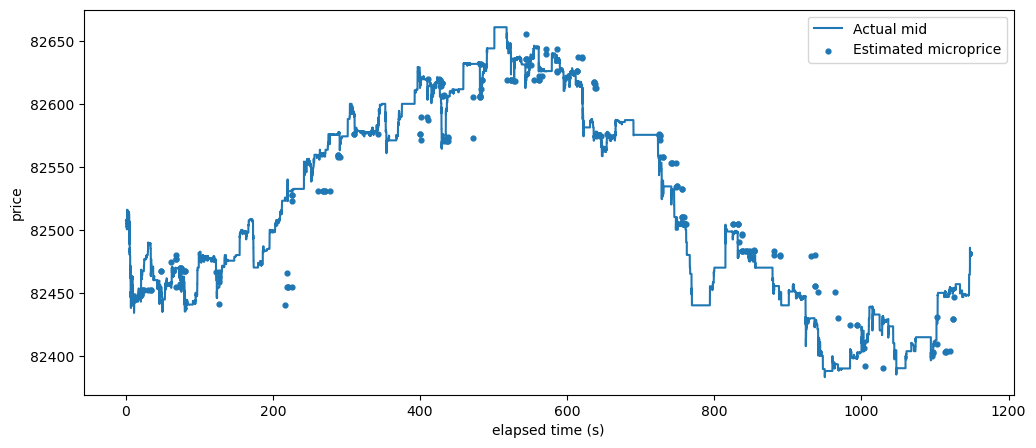

In [122]:
plot_df = df_with_microprice[df_with_microprice['microprice_estimate'].notna()].copy()

plt.figure(figsize=(12, 5))
plt.plot(df_with_microprice['time_s'], df_with_microprice['mid'], label='Actual mid')
plt.scatter(plot_df['time_s'], plot_df['microprice_estimate'], s=12, label='Estimated microprice')
plt.xlabel('elapsed time (s)')
plt.ylabel('price')
plt.legend()
plt.show()

In [123]:
import numpy as np
import pandas as pd

def evaluate_event_horizon(T_work, G, raw_index_col, n_moves_list):
    results = []
    move_rows = T_work.index[T_work['dM'] != 0].to_numpy()

    for h in n_moves_list:
        preds = []
        reals = []
        times = []

        for k in range(len(move_rows) - h):
            origin_row = move_rows[k]
            target_row = move_rows[k + h]

            pred_change = T_work.loc[origin_row, 'microprice_adjustment_now']
            real_change = T_work.loc[target_row, 'mid'] - T_work.loc[origin_row, 'mid']
            dt_sec = (T_work.loc[target_row, 'timestamp'] - T_work.loc[origin_row, 'timestamp']) / 1e6

            preds.append(pred_change)
            reals.append(real_change)
            times.append(dt_sec)

        preds = np.array(preds)
        reals = np.array(reals)

        direction_acc = np.mean(np.sign(preds) == np.sign(reals))
        corr = np.corrcoef(preds, reals)[0, 1] if len(preds) > 1 else np.nan
        mse = np.mean((preds - reals) ** 2)

        results.append({
            'n_moves': h,
            'n_obs': len(preds),
            'direction_acc': direction_acc,
            'corr': corr,
            'mse': mse,
            'median_horizon_sec': np.median(times),
            'mean_horizon_sec': np.mean(times),
        })

    return pd.DataFrame(results)

def evaluate_clock_horizon(df, horizons_sec):
    results = []

    ts = df['timestamp'].to_numpy().astype(float)
    mid = df['mid'].to_numpy().astype(float)
    signal = (df['microprice_estimate'] - df['mid']).to_numpy().astype(float)

    valid = ~np.isnan(signal)

    for h in horizons_sec:
        preds = []
        reals = []

        for i in np.where(valid)[0]:
            future_time = ts[i] + h * 1e6
            j = np.searchsorted(ts, future_time, side='left')

            if j < len(df):
                preds.append(signal[i])
                reals.append(mid[j] - mid[i])

        preds = np.array(preds)
        reals = np.array(reals)

        direction_acc = np.mean(np.sign(preds) == np.sign(reals))
        corr = np.corrcoef(preds, reals)[0, 1] if len(preds) > 1 else np.nan
        mse = np.mean((preds - reals) ** 2)

        results.append({
            'horizon_sec': h,
            'n_obs': len(preds),
            'direction_acc': direction_acc,
            'corr': corr,
            'mse': mse,
        })

    return pd.DataFrame(results)

In [124]:
eval_df = evaluate_event_horizon(
    T_work=T_with_microprice,
    G=G6,
    raw_index_col=T_with_microprice.columns[0],
    n_moves_list=[1, 2, 4, 6, 8, 10]
)

eval_df

,n_moves,n_obs,direction_acc,corr,mse,median_horizon_sec,mean_horizon_sec
0,1,226,0.730088,0.175812,102.698719,0.4045,4.949867
1,2,225,0.400000,0.073763,198.139256,3.7520,9.935813
2,4,223,0.488789,0.113227,394.251890,9.4070,20.023892
3,6,221,0.520362,0.145617,626.483666,19.7840,30.217652
4,8,219,0.502283,0.154419,871.346417,26.6210,40.520781
5,10,217,0.511521,0.156377,1141.795312,44.0240,50.936175


In [125]:
clock_eval = evaluate_clock_horizon(
    df_with_microprice,
    horizons_sec=[1, 2, 5, 10, 20, 30, 60]
)

clock_eval

,horizon_sec,n_obs,direction_acc,corr,mse
0,1,221,0.457014,-0.021684,676.104705
1,2,221,0.434389,-0.081608,735.468451
2,5,221,0.389140,-0.105243,906.325607
3,10,221,0.361991,-0.080452,1282.857463
4,20,221,0.393665,-0.100609,1685.807904
5,30,217,0.400922,-0.130827,2087.502002
6,60,208,0.403846,-0.254468,2497.338294


A good timescale is where:
1. correlation is highest
2. direction accuracy is meaningfully above 50%
3. results are stable, not noisy
4. the average realized horizon is practical for your use